Week 2 Assignment


Netflix dataset


Data Loading and Basic Checking

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [3]:
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Data Cleaning

Handle Missing Values

In [7]:
df['director'].fillna("Unknown", inplace=True)
df['cast'].fillna("Unknown", inplace=True)
df['country'].fillna("Unknown", inplace=True)
df.dropna(subset=['rating'], inplace=True)

/tmp/ipython-input-531106724.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna("Unknown", inplace=True)
/tmp/ipython-input-531106724.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

Standardize Casing

In [17]:
df['type'] = df['type'].str.upper()
df['rating'] = df['rating'].str.upper()

Convert Date Column

In [20]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df['year_added'] = df['date_added'].dt.year

Univariate & Bivariate Analysis


Most Common Rating

In [21]:
df['rating'].value_counts().head(1)

,count
rating,
TV-MA,3207


Top 5 Countries by Content

In [22]:
df['country'].value_counts().head(5)

,count
country,
United States,2818
India,972
Unknown,830
United Kingdom,419
Japan,244


Movie vs TV Show Distribution

In [24]:
df['type'].value_counts()

,count
type,
MOVIE,6129
TV SHOW,2674


Average Release Year by Type

In [25]:
df.groupby('type')['release_year'].mean()

,release_year
type,
MOVIE,2013.120574
TV SHOW,2016.607704


Trend Analysis

Titles Added Each Year

In [26]:
titles_per_year = df['year_added'].value_counts().sort_index()
titles_per_year

,count
year_added,
2008.0,2
2009.0,2
2010.0,1
2011.0,13
2012.0,3
2013.0,11
2014.0,24
2015.0,82
2016.0,428


Check Trend

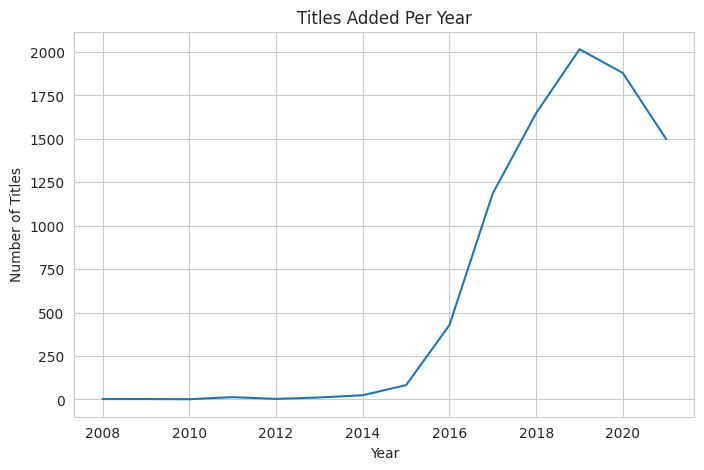

In [27]:
titles_per_year.plot(kind='line', figsize=(8,5))
plt.title("Titles Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

Release Year vs Rating

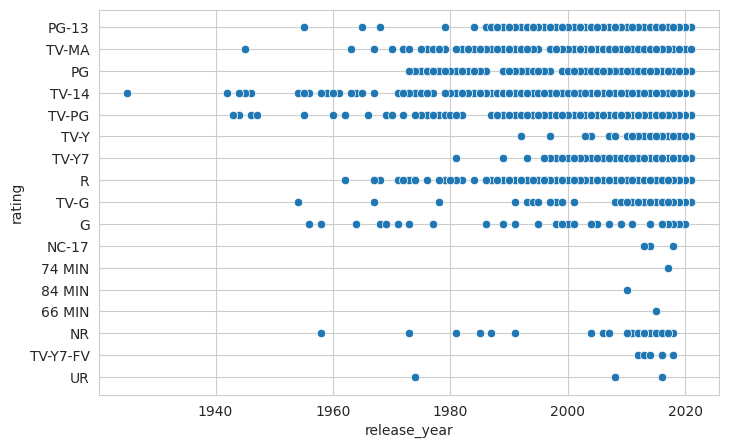

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='release_year', y='rating', data=df)
plt.show()

Visualizations


Count Plot vs Movies vs TV Shows


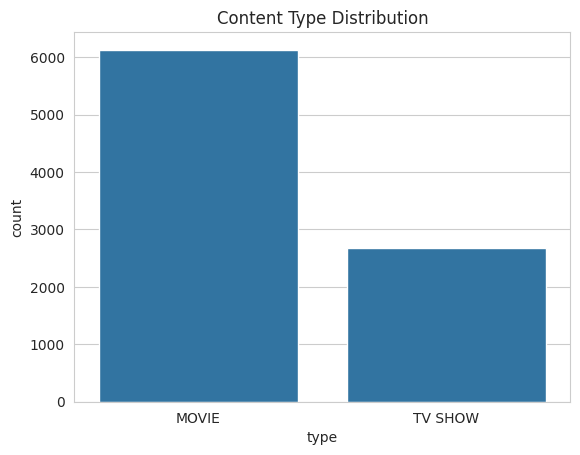

In [29]:
sns.countplot(x='type', data=df)
plt.title("Content Type Distribution")
plt.show()

Top 5 Countries Bar Chart

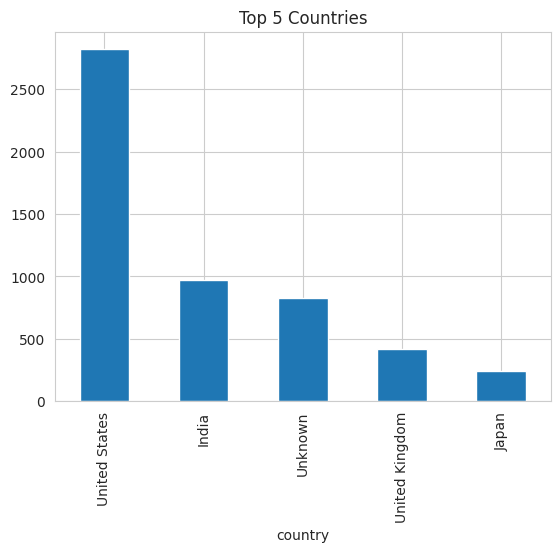

In [30]:
top5 = df['country'].value_counts().head(5)
top5.plot(kind='bar')
plt.title("Top 5 Countries")
plt.show()

Yearly Additions Line Chart

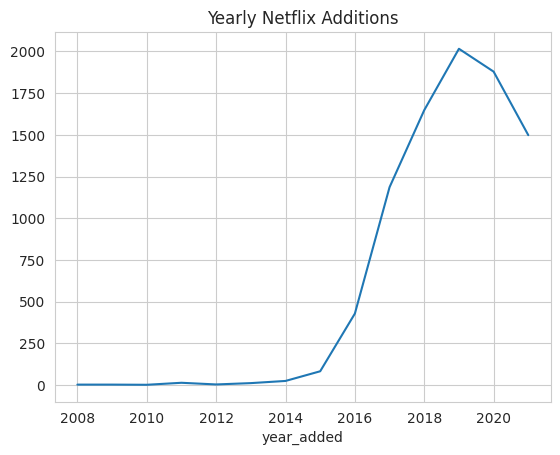

In [31]:
titles_per_year.plot(kind='line')
plt.title("Yearly Netflix Additions")
plt.show()

Scatter Plot – Release Year vs Duration

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-4281754560.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


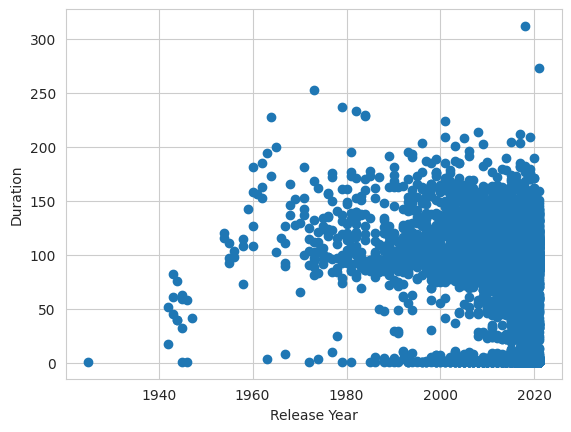

In [32]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

plt.scatter(df['release_year'], df['duration_num'])
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.show()

Correlation Heatmap

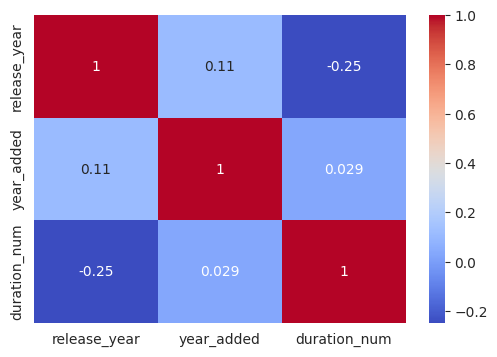

In [33]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Conclusion and  Insights

Netflix has more Movies than TV Shows, showing a stronger focus on film content. The most common rating is TV-MA, which indicates that much of the content targets mature audiences. The United States contributes the highest number of titles, making it the top content-producing country. Additionally, content additions increased significantly after 2015, reflecting rapid growth in Netflix’s library.


TV-MA is the most common rating.

USA is the top content-producing country.

Content additions increased significantly after 2015 paragrap